<a href="https://colab.research.google.com/github/geraldiakmal2380/PCVK_Ganjil_2026/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Apa yang dilakukan di praktikum ini?

# **Disclaimer of AI Use :**
Ringkasan ini dibuat dengan bantuan AI. AI membantu saya untuk belajar dan mengerjakan tugas ini.

# **1.Inverse Citra:**
Nilai citra dibalik dengan mengurangkan nilai maksimum piksel (255) dengan nilai piksel asli, sehingga menghasilkan citra negatif.

#**2.Transformasi Contrast:**
Kontras dimodifikasi dengan menghitung Contrast Correction Factor (F), kemudian diaplikasikan pada setiap piksel warna (R, G, B) yang nilainya dibatasi menggunakan fungsi Truncate agar tetap di rentang 0-255

#**3.Transformasi Logarithmic:**
Memetakan rentang input keabuan yang sempit menjadi lebih lebar dengan rumus s = c * log(1 + r)

#**4.Grayscale:**
Mengubah citra warna menjadi keabuan (8 bit) menggunakan tiga metode:

**-Averaging:** Merata-rata channel R, G, B.   
**-bightness:** Merata-rata nilai tertinggi dan terendah dari channel R, G, B.   
**-Luminance:** Memberikan bobot spesifik pada tiap channel (0.21R + 0.72G + 0.07B)

#**5.Gamma Correction:**
Menyesuaikan kecerahan kurva gambar dimana input dipangkatkan dengan invers dari nilai gamma

#**6.Simulasi Bit Depth:**
Mengurangi Bit Depth. Misalnya dari 8 bit ke 7 bit dan lain2.

#**7.Average Denoising dan PSNR:**
Menghilangkan noise dengan merata ratakan pixel pada kumpulan gambar yang sama. Diukur kualitasnya dengan Peak Signal to Noise Ratio (PSNR)

#**8.Image Masking:**
Menggunakan Logika AND, OR, NOT, XOR pada dua citra untuk memanipulasi area tertentu gambar.

# 1. Mount Google Drive ke sini


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Biasalah import module

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np #Ini dipake untuk truncate pada Nomor 4.
from google.colab.patches import cv2_imshow #Fix bug di google colab saat menampilkan gambar

# 3. Invert Warna Gambar

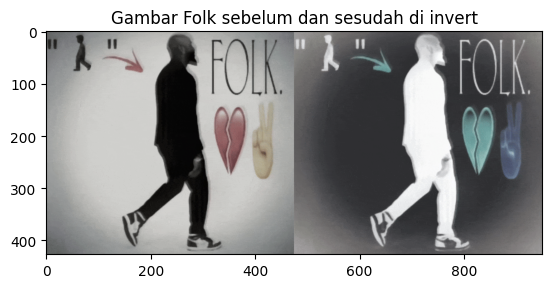

In [3]:
img_path = "/content/drive/MyDrive/Praktikum PCVK 2026/Folk.png"
original =  cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB) #baca gambarnya sekaligus langsung di konvert

# Cara invers warna adalah 255 dikurangi dengan value setiap warna dari pixel
orignal_but_inversed = 255 - original

final_frame = cv2.hconcat((original, orignal_but_inversed)) #jangan lupa kurungnya harus double. Entah kenapa ngebug kalau gak double
plt.title("Gambar Folk sebelum dan sesudah di invert")
plt.imshow(final_frame)

# 4. Ganti Contrast dan tingkat cahaya (GIMP is free bro)

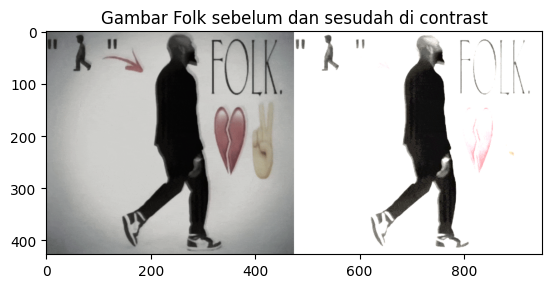

In [4]:
contrast_level = 120 #Ini value buat masukin ke gambar.

image_contrast = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)#Buat variabel baru lagi untuk masukan gambar

# Menghitung factor F sesuai rumus dari modul (real)
F = (259 * (contrast_level + 255)) / (255 * (259 - contrast_level))

#Setelah dihitung, aplikasikan ke rumus ke gambar dan truncate value nya dari 0 - 255 agar tidak ngebug.
image_contrast_converted = np.clip((F * image_contrast.astype(float) - 128) + 128, 0, 255).astype(np.uint8) #jujur gak paham ini buat apa

final_frame = cv2.hconcat((image_contrast, image_contrast_converted))
plt.title("Gambar Folk sebelum dan sesudah di contrast")
plt.imshow(final_frame)

# 5. Mengubah gambar menjadi Grayscale

**Averaging** di dapat dengan cara menjumlahkan warna setiap pixel lalu membaginya dengan 3. Misal ada pixel dengan warna (R: 126, G:150, B:80). Artinya (126 + 150 + 80) /3.

Nah kan ketemu rata2 nya adalah 116.67 (bulatkan jadi 117). Isi 117 di ketiga channel warna maka jadilah warna putih sedikit abu2 (coba aja di paint kalo gak percaya).

**Lightnes** Kurang lebih sama kayak averaging. tapi bedanya adalah kita ambil nilai maximum dan minimum dari ketiga channel warna. Setelah itu ditambahkan dan dibagi 2.

**Luminance** Ini cara paling ribet sebenarnya. Walau begitu, cukup ikuti rumus aja. Sebenarnya seh alasan dari dibalik rumusnya itu adalah mata manusia jauh lebih sensitif sama warna hijau. Saya bukan grafik desainer tapi ya gitulah.

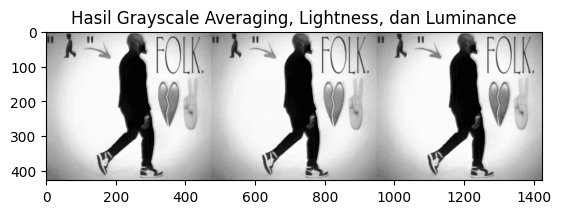

In [13]:
#buat variabel baru untuk memisahkan gambar dari sektor lain
image_grayscale = cv2.imread(img_path)

#pisah channel B, G, R. Bukan RGB
B, G, R = cv2.split(image_grayscale)

#metode 1 Averaging
img_average = (R.astype(float) + G.astype(float) + B.astype(float)) /3
img_average = img_average.astype(np.uint8)

#Metode 2 Lightness (mengambil nilai min dan max dari ketiga channel warna)
img_max = np.maximum(np.maximum(R,G), B).astype(float)
img_min = np.minimum(np.minimum(R,G), B).astype(float)

img_ligthness = ((img_max + img_min)/2).astype(np.uint8)

#Metode 3 luminance (rumus dari modul saya hanya ngikut saja)
img_luminance = (0.21*R + 0.72*G + 0.07*B).astype(np.uint8)


#step 4 print gambarnya
plt.title("Hasil Grayscale Averaging, Lightness, dan Luminance")
plt.imshow(cv2.hconcat((img_average, img_ligthness, img_luminance)), cmap='gray')



# 6. Sama seperti atas yaitu grayscale, tapi biarin warna merah tetap di gambar

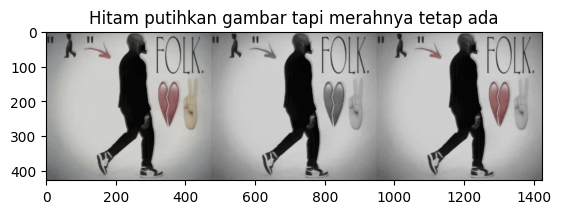

In [15]:
#Kita buat salinan gamabar luminance menjadi 3 channel (B, G, R) agar seragam dengan citra asli
img_luminance_copy = cv2.merge([img_luminance, img_luminance, img_luminance])
img_selective = img_luminance_copy.copy()

#deteksi dimana pixel red mendominasi warna green dan blue
#Treshold ini bisa disessuaikan. Misalnya Red lebih besar dari green + 20 atau red lebih besar dari Blue + 20. (20 itu bisa diganti angkanya terserah mau berapa)
mask_red = (R > G+20) & (R > B+20)

#Timpa warna yang terdeteksi dengan warna dari gambar asli
img_selective[mask_red] = original[mask_red]

plt.title("Hitam putihkan gambar tapi merahnya tetap ada")
plt.imshow(cv2.hconcat((original, img_luminance_copy , img_selective)))
